In [21]:
# Import core libraries for data manipulation, visualization,
# model training, and regression evaluation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
# Load transfer market insight dataset
df = pd.read_csv("transfer_insight.csv")

# Preview dataset to understand structure
df.head()

,player_id,name,age,position,speed,stamina,shooting,passing,dribbling,potential_score
0,1,Heather Daniels,20,GK,46,91,32,49,50,53
1,2,Theresa Caldwell,25,DEF,83,99,37,80,45,71
2,3,Mr. Jeffery Phillips,25,GK,69,74,46,34,49,53
3,4,Colleen White,25,GK,48,74,21,48,46,52
4,5,Courtney Santiago,21,FWD,79,62,77,53,93,75


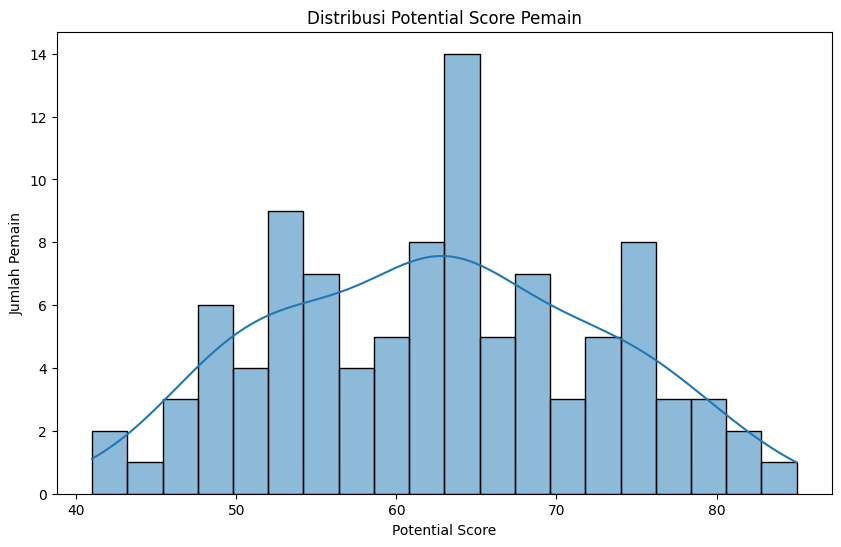

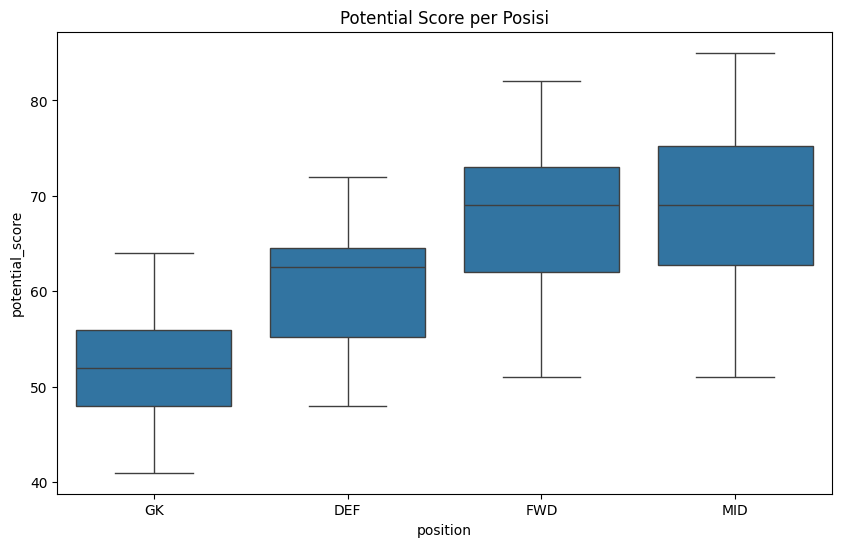

In [23]:
# Analyze distribution of target variable (potential score)
plt.figure(figsize=(10,6))
sns.histplot(df['potential_score'], bins=20, kde=True)
plt.title("Distribusi Potential Score Pemain")
plt.xlabel("Potential Score")
plt.ylabel("Jumlah Pemain")
plt.show()

# Compare potential score across positions
plt.figure(figsize=(10,6))
sns.boxplot(x='position', y='potential_score', data=df)
plt.title("Potential Score per Posisi")
plt.show()

In [24]:
# Define predictive features related to player performance attributes
features = ['age', 'speed', 'stamina', 'shooting', 'passing', 'dribbling']

# Separate feature matrix (X) and regression target (y)
X = df[features]
y = df['potential_score']

# Split dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Initialize Random Forest Regressor
# Suitable for capturing non-linear relationships in player attributes
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [26]:
# Train regression model on training data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
# Generate predictions on test set
y_pred = model.predict(X_test)

# Evaluate regression performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error (MSE): 30.52
R^2 Score: 0.72


Feature Importance:
     feature  importance
3   shooting    0.366284
1      speed    0.283173
5  dribbling    0.195687
4    passing    0.071700
2    stamina    0.056835
0        age    0.026321


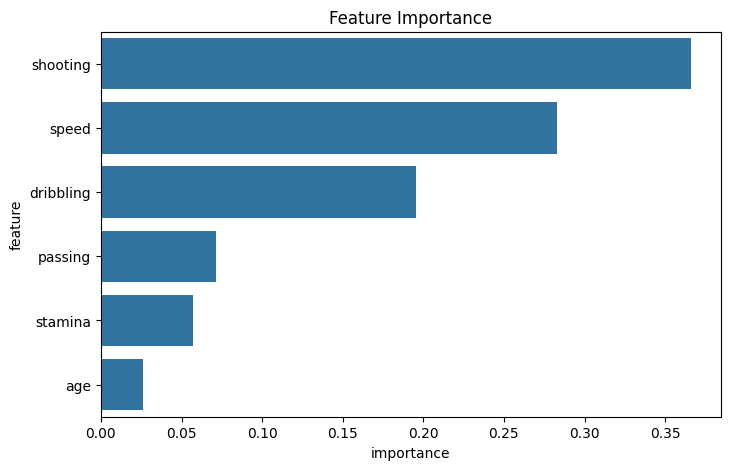

In [28]:
# Extract feature importance to identify key drivers of player potential
importances = model.feature_importances_

feature_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Feature Importance:")
print(feature_imp)

# Visualize importance ranking
plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feature_imp)
plt.title("Feature Importance")
plt.show()

In [29]:
# Predict potential score for all players (simulation purpose)
df['predicted_potential'] = model.predict(X)

In [30]:
# Identify top predicted potential player for each position
# Simulates scouting insight or transfer recommendation
top_players = df.groupby('position') \
    .apply(lambda x: x.nlargest(1, 'predicted_potential')) \
    .reset_index(drop=True)

print("Most potential players in each position:")
print(top_players[['name','position','predicted_potential',
                   'age','speed','stamina','shooting',
                   'passing','dribbling']])

Most potential players in each position:
              name position  predicted_potential  age  speed  stamina  \
0     Terry Holmes      DEF                69.32   22     91       87   
1    Paul Anderson      FWD                80.07   18     99       78   
2   Chad Carpenter       GK                62.14   20     70       76   
3  Melissa Holland      MID                83.07   24     88       83   

   shooting  passing  dribbling  
0        54       95         20  
1        86       48         92  
2        54       70         39  
3        87       76         91  


/tmp/ipython-input-587/2466528004.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'predicted_potential')) \
